## Izvlacenje dataset-a

In [48]:
import pandas as pd

In [49]:
df = pd.read_excel("../telekom_korisnici.xlsx",sheet_name=["Podaci","Rečnik_podataka"])
data = df["Podaci"].copy()
original = df["Podaci"].copy()

data_dict = df["Rečnik_podataka"].copy()


# Standardizacija

In [50]:
categories=["region","pol", "tip_paketa", "kanal_prodaje", "churn", "id_korisnika"]

for cat in categories:
    data[cat]=data[cat].astype("string").str.strip()

# Fala fajlu `problemi.csv` :)
map_region = {
    "beograd":"Beograd",
    "bg":"Beograd",
    "vojvodina":"Vojvodina",
    "šumadija i zapadna srbija":"Šumadija i Zapadna Srbija",
    "sumadija i zapadna srbija":"Šumadija i Zapadna Srbija",
    "južna i istočna srbija":"Južna i Istočna Srbija",
    "juzna i istocna srbija":"Južna i Istočna Srbija"
}

data["region"] = data["region"].str.lower().map(map_region)

map_pol={
    "m":"M",
    "ž":"Ž",
    "z":"M",
    "muski":"M",
    "muški":"M",
    "zenski":"Ž",
    "ženski":"Ž"
}

data["pol"]=data["pol"].str.lower().map(map_pol)

map_chrun={
    "yes":"Da",
    "1":"Da",
    "no":"Ne",
    "0":"Ne",
    "ne":"Ne",
    "da":"Da"
}
data["churn"] = data["churn"].str.lower().map(map_chrun)

map_tip={
    'post-paid':'Postpaid',
    'postpaid':'Postpaid',
    'pre-paid':'Prepaid',
    'biznis':'Biznis',
    'business':'Biznis',
    'prepaid':'Prepaid'
}

data["tip_paketa"]= data["tip_paketa"].str.lower().map(map_tip)

map_kanal={
    'poslovnica':'Poslovnica',
    'online':'Online',
    'call centar':'Call centar',
    'partner':'Partner'
}
data["kanal_prodaje"]=data["kanal_prodaje"].str.lower().map(map_kanal)

allowed = dict(zip(data_dict["kolona"], data_dict["dozvoljene vrednosti"].str.split("; ")))

categories=["region","pol", "tip_paketa", "kanal_prodaje", "churn"]

for col in categories:
    assert data[col].dropna().isin(allowed[col]).all(), col
    print(f"{col} {sorted(data[col].dropna().unique())}")



region ['Beograd', 'Južna i Istočna Srbija', 'Vojvodina', 'Šumadija i Zapadna Srbija']
pol ['M', 'Ž']
tip_paketa ['Biznis', 'Postpaid', 'Prepaid']
kanal_prodaje ['Call centar', 'Online', 'Partner', 'Poslovnica']
churn ['Da', 'Ne']


## Uklanjanje duplikata

In [51]:
pre = len(data)

data = data.drop_duplicates()

print("uklonjeno potpunih {}".format(pre-len(data)))
print("preostalih dupliranih id: {}".format(data["id_korisnika"].duplicated().sum()))

uklonjeno potpunih 32
preostalih dupliranih id: 0


## Tekst u brojeve

In [52]:
#priznajem da sam se pomogao uputstvom
import numpy as np

def u_broj(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v,(float,int)):
        return float(v)

    num = str(v).lower().replace("rsd","").replace("din","").strip()

    if "," in num and "." in num:
        num=num.replace(".","").replace(",",".")

    elif "," in num:
        num=num.replace(",",".")

    pos = num.rfind(".")
    size = len(num)

    num = num.replace(".", "")
    num = int(num) / np.power(10, size - pos - 1)

    return float(num)



for col in ["mesecni_racun_rsd", "potrosnja_gb"]:
    nan_pre = data[col].isna().sum()
    data[col]= data[col].map(u_broj)
    print(f"{col} {nan_pre} {data[col].isna().sum()}")


mesecni_racun_rsd 36 36
potrosnja_gb 36 36


## Parsiranje datuma

In [53]:
datumi = data["datum_aktivacije"].astype("string").str.strip()

iso_std = pd.to_datetime(datumi,format="%Y-%m-%d",errors="coerce")

serbian = pd.to_datetime(datumi,format="%d.%m.%Y.",errors="coerce")

us = pd.to_datetime(datumi,format="%m/%d/%Y",errors="coerce")

not_valid = iso_std > pd.Timestamp("2026-09-01")

data["datum_aktivacije"] = iso_std.fillna(serbian).fillna(us) #popuni falinke u iso parsiranju sa serbianom ili us-om
print(f"ISO {iso_std.notna().sum()} SRB {serbian.notna().sum()} US {us.notna().sum()}")


print(f"buducnost {not_valid.sum()}")
data.loc[not_valid,"datum_aktivacije"]=pd.NaT


print(f"Nevalidni {not_valid.isna().sum()}") #logicno da nema, jer smo zakrpili necim pre 2 reda



ISO 1030 SRB 110 US 60
buducnost 6
Nevalidni 0


## Nelogične vrednosti

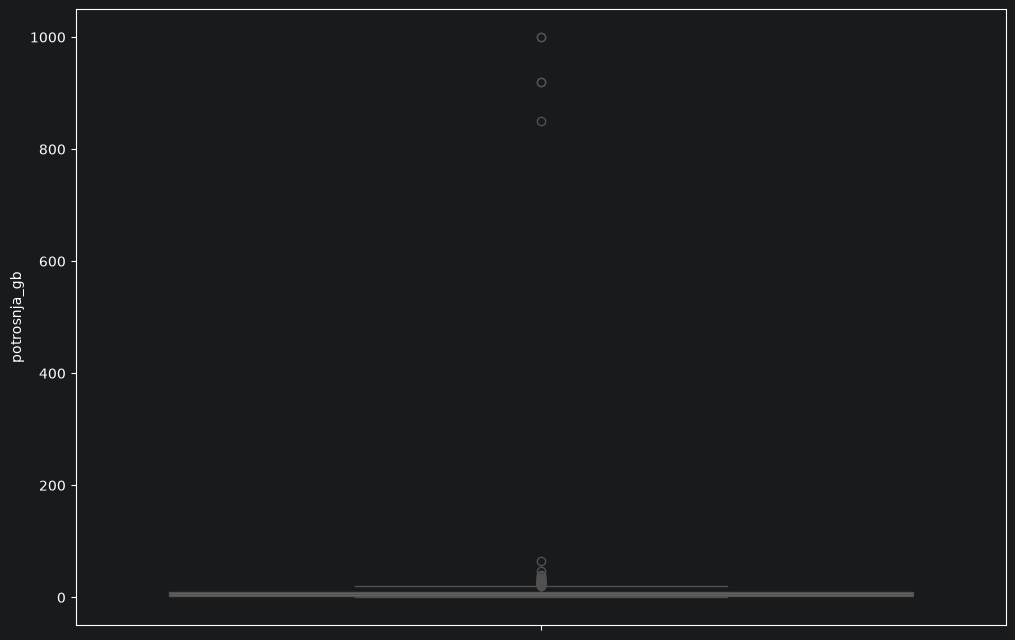

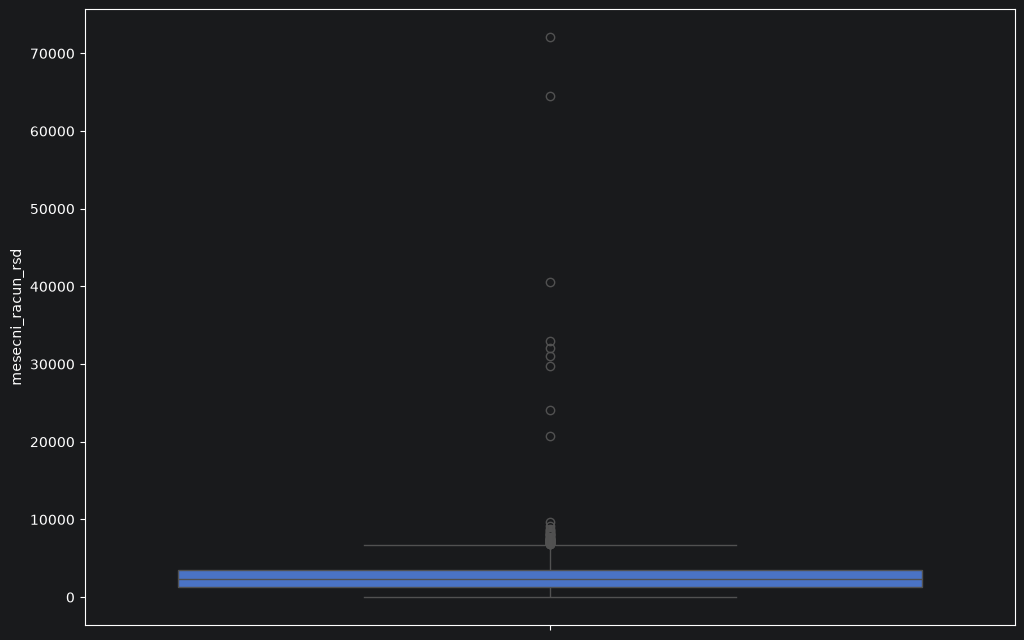

godine 7 [-26.0, 127.0, 135.0, -19.0, 150.0, -21.0, 150.0]
staz_meseci 5 [-4, -9, -9, -3, -3]
mesecni_racun_rsd 0 []
minuti_poziva 8 [-139, -98, 7500, 7500, -62, -14, 7500, 7500]
potrosnja_gb 5 [850.0, 999.9, 920.5, 999.9, 920.5]
broj_sms 0 []


In [54]:
import matplotlib.pyplot as plt, seaborn as sb

plt.figure(figsize=(12,8))
sb.boxplot(data=data["potrosnja_gb"])
plt.show()

plt.figure(figsize=(12,8))
sb.boxplot(data=data["mesecni_racun_rsd"])
plt.show()


# Sporne kolone
# godine, staz_meseci, mesecni_racun_rsd minuti_poziva

failed_cols={
    "godine": lambda s:(s<18) | (s>100),
    "staz_meseci": lambda s: s<1,
    "mesecni_racun_rsd": lambda s: s<0,
    "minuti_poziva": lambda s: (s<0) | (s>5000),
    "potrosnja_gb": lambda s: (s<0) |  (s>150),
    "broj_sms": lambda s: (s<0),
}

for col,rule in failed_cols.items():
    result = rule(data[col]) & data[col].notna()
    print(col,result.sum(), data.loc[result,col].tolist())
    data.loc[result,col] = np.nan

ten = data["mesecni_racun_rsd"]>15000


Kako je $\frac{9}{1260} < 1 \%$ u sustini to je zanemarivo malo s aspekta obima uzorka.

In [55]:
data_copy = data.copy()

display(data_copy["mesecni_racun_rsd"].describe())

records = data_copy.loc[ten]

data_copy = data_copy.drop(records.index)

display(data_copy["mesecni_racun_rsd"].describe())

records = data.loc[ten]

data.drop(records.index,inplace=True)

count     1164.000000
mean      2961.697167
std       3880.865830
min          0.125000
25%       1366.000000
50%       2359.000000
75%       3530.000000
max      72090.000000
Name: mesecni_racun_rsd, dtype: float64

count    1155.000000
mean     2683.701733
std      1725.109720
min         0.125000
25%      1359.500000
50%      2342.000000
75%      3511.500000
max      9675.000000
Name: mesecni_racun_rsd, dtype: float64

Naknadnom analizom je utvrdjeno da se normalnost raspodele velicine `mesecni_racun_rsd` se ne menja, jer je Shapiro-Wilco prijavio za vrednosti (pre i posle):
```
0.3811855574572757 1.4706799491645429e-52
0.9183899941053502 1.769233464734458e-24
```
sto za nivo znacajnosti od $5\%$ govori da raspodela NIJE normalna prema tome prosek ne moze biti dobar pokazatelj. Odluka o izbacivanju zavisi od toga koliko su druge velicine pogodjene ovom promenom (da li sadrze outlier-e i sl).

## Outlier-i

In [56]:
for col in ["mesecni_racun_rsd","potrosnja_gb"]:
    q1,q3 = data[col].quantile([0.25, 0.75])
    iqr = q3-q1
    lower,upper = q1-1.5*iqr,q3+1.5*iqr

    data[f"{col}_outlier"] = (data[col] < lower) | (data[col]>upper)

    print(col, data[f"{col}_outlier"].sum(), lower,upper)

outlier = (data["mesecni_racun_rsd"] < lower) | (data["mesecni_racun_rsd"]>upper)

outlier_table = data.groupby("tip_paketa").apply(lambda s: outlier.loc[s.index].sum())

print(f"Biznis korisnici: cca {((outlier_table["Biznis"]/outlier_table.sum())*100).round()}%")

# Pitanje na sta se tacno misli pod odstupanjem od z-score pravila ?

mesecni_racun_rsd 42 -1868.5 6739.5
potrosnja_gb 44 -7.45 20.950000000000003
Biznis korisnici: cca 15.0%


### Boxplot posle

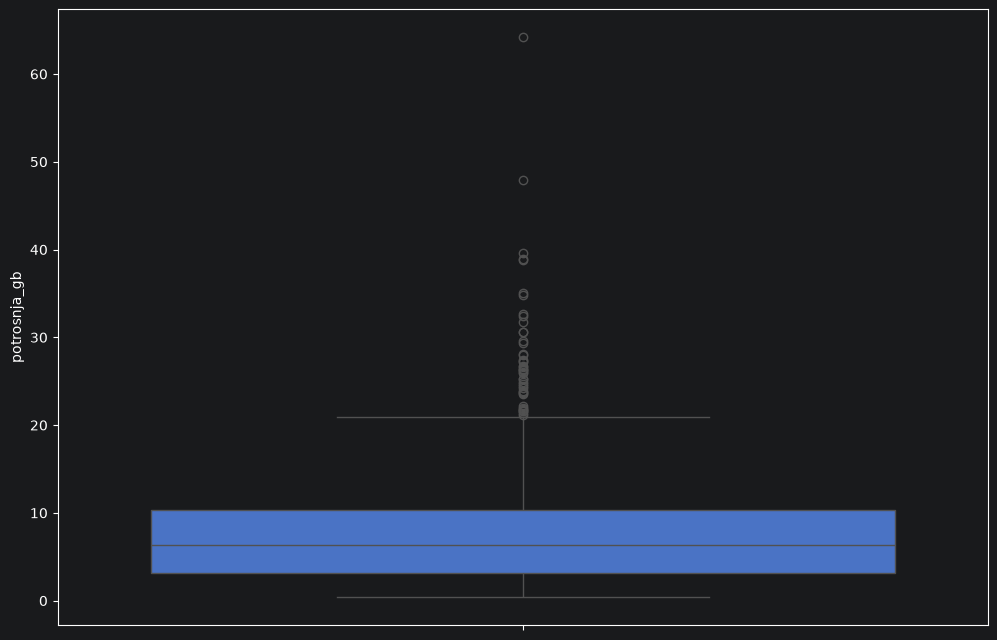

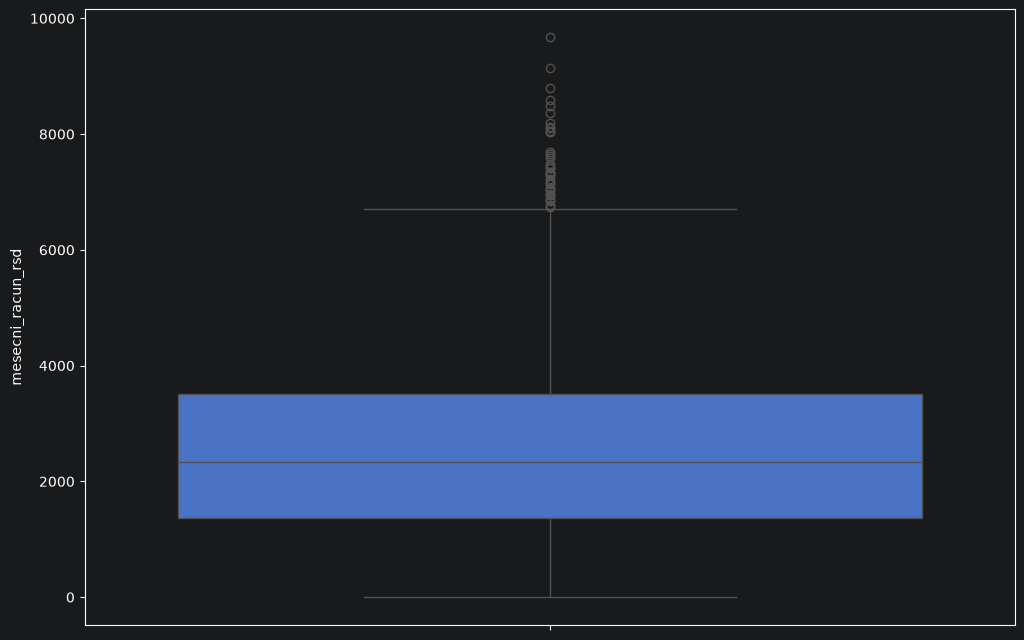

In [57]:
plt.figure(figsize=(12,8))
sb.boxplot(data=data["potrosnja_gb"])
plt.show()

plt.figure(figsize=(12,8))
sb.boxplot(data=data["mesecni_racun_rsd"])
plt.show()

## Nedostajuce vrednosti

In [58]:
data["godine_inputirano"] = data["godine"].isna()

data["godine"] = data["godine"].fillna(data.groupby("tip_paketa")["godine"].transform("median"))

# Racun - uzimamo medijanu po grupama i gledamo da za svaku opservaciju gde fali uklopimo medijanu pripadajuceg regiona
data["mesecni_racun_rsd"] = data["mesecni_racun_rsd"].fillna(
        data.groupby("region")["mesecni_racun_rsd"].transform("median"))

# Ocenu ne cackamo jer ne mozemo da pricamo nesto za sta nemamo pokrice (ocena je subjektivna stvar i ne moze se aproksimirati prosekom ili sl merama)
data["ocena_poznata"] = data["ocena_zadovoljstva"].notna()

### Za mentora: U odnosu na šta se traži medijana za `staz_meseci` ?

In [59]:
staz_median = data["staz_meseci"].median()
for index,row in data.iterrows():
    if pd.isna(row["staz_meseci"]):
        if pd.isna(row["datum_aktivacije"]):
            data.loc[index,"staz_meseci"]=staz_median # ovde je kvrga, u odnosu na sta gledamo staz ?
        else:
            data.loc[index,"staz_meseci"]= round((pd.Timestamp("2026-09-01")-row["datum_aktivacije"]).days/30.4)

In [60]:
for index,row in data.iterrows():
    if pd.isna(row["region"]):
        data.loc[index,"region"]="Nepoznato"
    if pd.isna(row["kanal_prodaje"]):
        data.loc[index,"kanal_prodaje"]="Nepoznato"

In [61]:
data["potrosnja_gb"] = data["potrosnja_gb"].fillna(data.groupby("tip_paketa")["potrosnja_gb"].transform("median"))
data["minuti_poziva"]=data["minuti_poziva"].fillna(data["minuti_poziva"].median())

In [62]:
print(data.isna().sum()[data.isna().sum() > 0])

datum_aktivacije       6
ocena_zadovoljstva    96
dtype: int64


## Dodela tipova

In [63]:
display(data.info())

data["godine"]=data["godine"].round().astype("Int64")

for cat in ["region","pol", "tip_paketa", "kanal_prodaje", "churn"]:
    data[cat]=data[cat].astype("category")

data["datum_aktivacije"]=data["datum_aktivacije"].astype("datetime64[ns]")


# starosna i staz grupa
data["starosna_grupa"]=pd.cut(
    data["godine"].astype(float),
    bins=[17,29,44,59,100],
    labels=["18-29","30-44","45-59","60+"],
    include_lowest=True,
)
# churn flag
churn_cat={
    "Da":1,
    "Ne":0
}
data["churn_flag"] = data["churn"].map(churn_cat)

# ima rekl
data["ima_reklamaciju"] = (data["broj_reklamacija"]>0).map({True:"Da",False:"Ne"})

# godina akt
data["godina_aktivacije"]=data["datum_aktivacije"].dt.year

# racun po gb
data["racun_po_gb"] = np.where(data["potrosnja_gb"]>0, data["mesecni_racun_rsd"]/data["potrosnja_gb"], np.nan)
data["ima_potrosnje"] = (data["potrosnja_gb"]>0).map({True:"Da",False:"Ne"})

#grupa po stazu
data["staz_grupa"] = pd.cut(data["staz_meseci"].astype(float),[0,12,36,72,200],
                            labels=["go 1 god","1-3 god","3-6 god","6+ god"])

data.to_csv("korisnici_clean.csv",index=False)
print(data.shape)

<class 'pandas.DataFrame'>
Index: 1191 entries, 0 to 1231
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id_korisnika               1191 non-null   string        
 1   region                     1191 non-null   str           
 2   pol                        1191 non-null   str           
 3   godine                     1191 non-null   float64       
 4   tip_paketa                 1191 non-null   str           
 5   staz_meseci                1191 non-null   float64       
 6   mesecni_racun_rsd          1191 non-null   float64       
 7   potrosnja_gb               1191 non-null   float64       
 8   minuti_poziva              1191 non-null   float64       
 9   broj_sms                   1191 non-null   float64       
 10  broj_reklamacija           1191 non-null   int64         
 11  kanal_prodaje              1191 non-null   str           
 12  datum_aktivacije      

None

(1191, 26)


## Poređenje

In [64]:
numeric = ["godine","staz_meseci","mesecni_racun_rsd","potrosnja_gb","minuti_poziva"]

comparison=[]

original["mesecni_racun_rsd"] = pd.to_numeric(original["mesecni_racun_rsd"],errors="coerce")




In [65]:
import pandas as pd
from scipy import stats


def mere(x:pd.Series)->dict:
    x=pd.to_numeric(x,errors="coerce").dropna().astype(float)
    if x.empty:
        return {}

    positive = x[x>0]

    summary = stats.describe(x)

    q3=x.quantile(q=0.75)
    q1=x.quantile(q=0.25)

    return{
        "kolona":x.name,
        "n":len(x),
        "aritmeticka_sredina":x.mean(),
        "geometrijska_sredina":stats.gmean(x),
        "harmonijska_sredina":stats.hmean(x),
        "10_perc_trimovana":stats.trim_mean(x,proportiontocut=0.1),
        "raspon":x.describe().loc['max']-x.describe().loc['min'],
        "varijansa_uzorka":x.var(),
        "std_devijacija":x.std(),
        "IQR":q3-q1,
        "koeficijent_varijacije_perc":stats.variation(x),
        "asimetrija":stats.skew(x),
        "spljostenost":stats.kurtosis(x,bias=False),
        "q1":q1,
        "q3":q3,
        "p95":x.quantile(0.95),
        "mod":x.mode().iloc[0],
        "medijana":x.median()
    }

values=[]
for col in data.columns:
    value=mere(data[col])
    if value:
        values.append(value)
    else:
        continue

pd.DataFrame(values).to_csv("mere_cisto.csv",index=False)


/home/machina/Desktop/praksa-posao/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:232: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/home/machina/Desktop/praksa-posao/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:601: RuntimeWarning: The harmonic mean is only defined if all elements are non-negative; otherwise, the result is NaN.
  res = hypotest_fun_out(*samples, **kwds)
